X_train shape: (14241, 30, 18)


d:\RUL\DL\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,649 (248.63 KB)

 Trainable params: 63,649 (248.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0138 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 2/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0061 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 3/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0039 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 4/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0030 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 5/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0018 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 6/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0013 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 7/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 9.9245e-04 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 8/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 8.7670e-04 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 9/100
446/446 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 7.9607e-04 - val_loss: 0.0073 - l

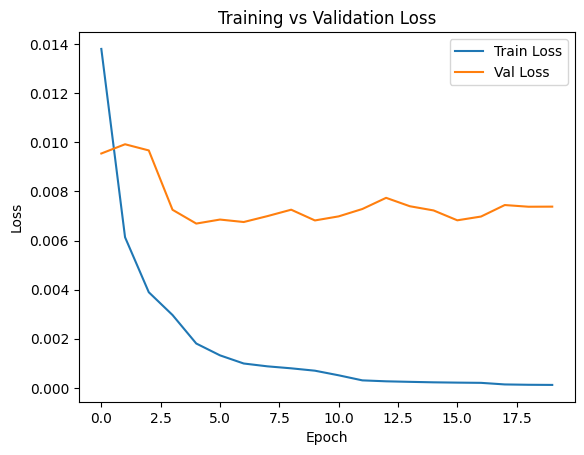

In [1]:



import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau
import math
import matplotlib.pyplot as plt
import random

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# -------------------------
# LOAD DATA
# -------------------------
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

timesteps = X_train.shape[1]
features = X_train.shape[2]
print("X_train shape:", X_train.shape)
sample_weights = np.where(y_train <= 80, 2.0, 1.0)
y_train = y_train/ 125.0
y_val = y_val / 125.0
# -------------------------
# BUILD MODEL
# -------------------------
model_bidirectional = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(timesteps, features)),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1)
])

model_bidirectional.compile(
    optimizer=Adam(learning_rate=0.001,clipnorm = 1.0),
    loss='mse'
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-5
)

model_bidirectional.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history2 = model_bidirectional.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

y_train_predi = model_bidirectional.predict(X_train).flatten()*125
y_val_predi = model_bidirectional.predict(X_val).flatten()*125

y_train_actual = y_train * 125  # ← denormalize the actuals too
y_val_actual = y_val * 125

train_rmsee = math.sqrt(mean_squared_error(y_train_actual, y_train_predi))
val_rmsee = math.sqrt(mean_squared_error(y_val_actual, y_val_predi))

print("\n=== LSTM RESULTS ===")
print("Train RMSE:", train_rmsee)
print("Val RMSE:", val_rmsee)


plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [2]:
# -------------------------
# LOAD TEST DATA
# -------------------------
X_test = np.load("../data/processed/X_test_final.npy")
rul_test = np.load("../data/processed/rul_test.npy")

# -------------------------
# PREDICT
# -------------------------
y_test_pred = model_bidirectional.predict(X_test).flatten()

# -------------------------
# RMSE
# -------------------------
y_test_pred = y_test_pred * 125.0
test_rmse = math.sqrt(mean_squared_error(rul_test, y_test_pred))

print("\n=== TEST RESULTS ===")
print("Test RMSE:", test_rmse)

# -------------------------
# SAMPLE PREDICTIONS
# -------------------------
for i in range(10):
    print(
        f"Actual: {rul_test[i]} | "
        f"Predicted: {round(y_test_pred[i], 2)}"
    )

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== TEST RESULTS ===
Test RMSE: 27.44696034762718
Actual: [112.] | Predicted: 122.91999816894531
Actual: [98.] | Predicted: 127.13999938964844
Actual: [69.] | Predicted: 64.30000305175781
Actual: [82.] | Predicted: 98.33000183105469
Actual: [91.] | Predicted: 103.76000213623047
Actual: [93.] | Predicted: 96.9800033569336
Actual: [91.] | Predicted: 62.470001220703125
Actual: [95.] | Predicted: 49.88999938964844
Actual: [111.] | Predicted: 124.41000366210938
Actual: [96.] | Predicted: 33.09000015258789
